# Classifying the Sex of Eastern Red Tailed Hawks

## Problem Statement
Conservationists in Illinois track bird species to better understand and possibly assist in local conservation efforts. Conservationists would like to track the sex of the species that are observed.

The Eastern Red-Tailed Hawk is of interest to our local conservationists. However, unlike some bird species the Eastern Red-Tailed Hawk cannot be visually differentiated by sex. That is, they are not sufficiently sexually dimorphic that you can just know by looking at them.

Researchers can always genotype to determine sex, but this is slow. Researchers have attempted to classify hawk's sex by live capturing and measuring different parts of their body.

We are going to see if we can use machine learning to help with classification. Keep in mind this is a **binary classification** task with a very small sample size.  



## Focal Study and Data

* Title: [Sex Determination of Eastern Red-tailed Hawks (Buteo jamaicensis borealis) Using Morphological Measurements](https://digitalcommons.iwu.edu/jwprc/2023/schedule/43/)
* Authors: Steven Burkett, Meredith Fraker, Miles Keeton, Eleanor Blew, Richard Alvey, and Given Harper
* Institution: Illinois Wesleyan University
* Year: 2023
* Abstract: Red-tail hawks (Buteo jamaicensis; RTHAs) are one of the most common large diurnal raptors found throughout North America. While there are 14 recognized subspecies, the Eastern RTHA (B. j. borealis) is the only one that breeds and winters in Illinois. Female Eastern RTHAs are typically larger than males, but there is no reliable, non-invasive technique to sex individuals in-hand. Donohue and Dufty (2006) used discriminant function analysis of measurements of Western Red-tailed-Hawks (B. j. calurus) to successfully determine the sex of adults (98% accurate) and juveniles (97% accurate). Washburn et al. (2022) recently developed equations to predict the sex of B. j. borealis, which were 87.5% accurate for adults and 86% for juveniles. However, measurements for the western subspecies have not been tested to determine the sex of the eastern subspecies, which is the purpose of this study. We used morphometrics (wing chord, mass, hallux (hind talon) length, culmen (beak) size, and tail feather length) and equations described in both papers to determine the sex of 58 live-trapped and frozen B. j. borealis from the Illinois State University Museum. Hawks live-trapped during the winters of 2020 and 2021 were sexed using DNA extracted from feathers, while frozen hawks were sexed via necropsy. Our results using the Washburn et al. (2022) equations were 75% accurate in determining the sex of adults, and 88% for juveniles. In contrast, results using modified Donohue and Dufty (2006) equations yielded 90.6% accuracy for adults and 92.3% for juveniles. We are currently live- trapping additional hawks to increase our sample size to statistically test the efficacy of both equations.
* [Presentation by Burkett](https://www.youtube.com/watch?v=aakPZT-FTrk) describing the study in more detal

# Imports and DataFrame Construction

In [214]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, f1_score, log_loss
from sklearn.metrics import precision_score, recall_score, average_precision_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SequentialFeatureSelector


# Setting a style
sns.set_theme(style="whitegrid")


In [215]:
data = ',Bird,PCR SEX,Date,Age Class,Mass (g),Wing Chord (mm),Hallux (mm),Culmen (mm) ,Tail (mm) ,Tarsus (mm) \n0,2187-09099,M,12/13/2021,ASY,1244,380,28.85,27.54,218,83.95\n1,2187-09100,M,01/03/2022,ASY,1150,391,28.61,26.55,217,85.41\n2,2207-03552,F,01/05/2022,ASY,1442,414,31.71,28.85,215,87.75\n3,2187-15151,M,01/06/2022,ASY,1039,377,29.62,24.42,196,77.14\n4,2187-15152,M,01/12/2022,ASY,1011,385,31.68,26.46,212,81.68\n5,2207-03553,F,01/13/2022,ASY,1388,403,33.31,28.96,225,88.68\n6,2187-15153,M,01/14/2022,SY,959,367,28.89,26.46,196,81.68\n7,2187-15154,M,01/19/2022,SY,1049,370,27.73,27.25,220,79.51\n8,2187-15155,M,01/19/2022,SY,879,363,26.81,23.73,201,76.4\n9,2187-15156,M,01/20/2022,SY,1250,396,31.32,25.38,220,77.12\n10,2187-15157,M,01/20/2022,SY,1115,372,27.82,27.36,225,80.75\n11,1947-18268,M,01/28/2022,SY,854,367,26.55,23.38,215,79.7\n12,2187-15159,M,01/28/2022,ASY,975,375,32.16,26.3,205,75.34\n13,2207-03554,F,02/03/2022,SY,1442,414,32.62,28.85,215,87.75\n14,2187-15160,F,02/04/2022,ASY,1068,387,29.11,25.79,225,78.06\n15,2207-03555,F,02/07/2022,ASY,1500,413,35.17,31.53,226,86.09\n16,2207-03556,F,02/09/2022,SY,1363,394,33.71,29.14,224,87.23\n17,2187-15166,M,02/15/2022,ASY,1159,388,30.62,27.29,218,80.7\n18,2207-03557,F,02/23/2022,ASY,1381,419,32.33,29.8,220,86.23\n19,55,F,12/12/21,ASY,1291,401,29.03,25.39,220,85.0\n20,61,M,01/03/22,ASY,1388,363,25.12,24.54,186,80.0\n21,62,M,01/07/22,ASY,962,365,26.57,26.37,214,73.0\n22,63,F,01/29/22,ASY,1321,421,34.37,29.64,228,91.0\n23,64,M,01/29/22,ASY,988,407,28.44,27.61,210,87.0\n24,65,M,01/29/22,ASY,1051,381,30.09,27.15,212,79.0\n25,66,M,01/29/22,SY,957,369,28.48,27.65,202,77.0\n26,67,M,01/29/22,SY,1113,382,26.41,26.31,210,79.0\n27,68,M,1/30/22,ASY,1192,402,32.3,26.8,218,83.0\n28,69,F,2/6/22,ASY,1440,424,32.78,31.64,229,83.0\n29,70,F,2/6/22,ASY,1353,429,33.77,29.6,220,84.0\n30,71,F,2/6/22,ASY,1296,416,32.84,28.72,214,74.0\n31,72,F,2/13/22,ASY,1030,413,27.12,27.33,219,83.0\n32,73,F,2/19/22,SY,1326,395,29.27,27.46,229,90.0\n33,74,M,2/26/22,SY,762,375,27.89,23.27,198,81.0\n34,75,M,2/26/22,SY,829,374,27.7,24.04,201,79.0\n35,76,M,2/26/22,SY,1149,387,31.04,27.45,220,82.0\n36,77,M,2/27/22,ASY,1078,391,30.07,26.2,211,82.0\n37,78,M,2/27/22,SY,994,370,30.0,26.76,200,77.0\n38,1s,F,10/12/1998,HY ,1267,408,33.47,28.84,224,87.0\n39,3s,F,10/17/2013,HY ,1410,412,34.0,29.24,238,84.0\n40,4s,F,10/23/2007,SY,1189,399,31.95,27.75,216,75.0\n41,5s,M,03/21/2006,ASY,954,372,25.99,27.41,203,77.0\n42,6s,F,08/23/2014,ASY,1357,400,30.59,28.17,212,78.0\n43,7s,,12/12/1990,HY ,948,366,28.37,24.48,201,73.0\n44,8s,F,7/5/2008,ASY,1243,412,31.4,29.17,222,74.0\n45,9s,M,8/29/2014,ASY,1005,357,29.4,27.71,207,82.0\n46,10s,F,10/7/2020,HY ,1117,372,30.44,28.71,207,70.0\n47,11s,F,11/14/2009,ASY,815,371,29.41,26.87,199,83.0\n48,12s,M,3/12/2016,SY,820,357,28.89,25.26,207,83.0\n49,13s,M,01/17/2015,SY,798,358,26.05,24.07,193,73.0\n50,14s,M,07/06/2015,ASY,657,357,29.1,25.2,200,82.0\n51,15s,M,08/07/2018,SY,714,368,28.81,25.34,208,84.0\n52,16s,M,06/16/2000,ASY,1265,409,29.96,28.76,218,80.0\n53,17s,F,07/18/2000,HY ,617,366,28.79,24.69,211,84.0\n54,18s,F,09/19/1998,HY ,1222,407,33.2,29.39,246,78.0\n55,19s,F,11/25/2006,SY,1447,395,33.12,28.73,226,82.0\n56,20s,F,08/14/2016,SY,948,396,32.55,27.54,230,78.0\n57,21s,F,11/02/1993,,1373,394,31.35,27.96,217,74.0\n58,22s,M,02/19/2014,SY,578,353,24.76,24.52,200,75.0\n59,23s,F,11/15/2012,ASY,749,401,31.04,29.52,221,87.0\n60,24s,F,11/06/2006,HY ,1504,395,31.94,29.3,234,83.0\n61,25s,F,01/16/13,ASY,1434,418,31.46,29.05,237,83.0\n62,26s,M,11/18/00,SY,912,367,27.83,23.65,212,79.0\n63,27s,F,02/23/12,ASY,1569,408,32.94,30.33,231,85.0\n64,28s,F,11/14/00,ASY,1469,406,33.23,30.43,223,80.0\n65,29S,F,11/24/2015,HY ,1213,385,30.45,27.5,230,71.0\n'

df = pd.read_csv(StringIO(data))
df = df.iloc[:,1:]
df.columns = df.columns.str.lower().str.strip()
df.columns = [col[0] for col in df.columns.str.split()]
df.columns = df.columns.str.replace('pcr', 'sex')
df.age=df.age.str.strip() # clean rogur whitespace
# add in some age data for one bird
df.loc[df['bird']=='21s', 'age'] = 'HY'
df.head(3)

,bird,sex,date,age,mass,wing,hallux,culmen,tail,tarsus
0,2187-09099,M,12/13/2021,ASY,1244,380,28.85,27.54,218,83.95
1,2187-09100,M,01/03/2022,ASY,1150,391,28.61,26.55,217,85.41
2,2207-03552,F,01/05/2022,ASY,1442,414,31.71,28.85,215,87.75


In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bird    66 non-null     object 
 1   sex     65 non-null     object 
 2   date    66 non-null     object 
 3   age     66 non-null     object 
 4   mass    66 non-null     int64  
 5   wing    66 non-null     int64  
 6   hallux  66 non-null     float64
 7   culmen  66 non-null     float64
 8   tail    66 non-null     int64  
 9   tarsus  66 non-null     float64
dtypes: float64(3), int64(3), object(4)
memory usage: 5.3+ KB


We have one hawk with a missing value for sex. Since sex if the outcome of interest, we will drop that hawk.

In [217]:
print(df.shape)
df = df.dropna(axis=0)
print(df.shape)

(66, 10)
(65, 10)


## Helper Functions

In [218]:
def comboplot(y):
  # Create the violin plot (inner=None removes the tiny box inside)
  sns.violinplot(x='age', y=y, data=df, inner=None, color=".8")

  # Overlay the stripplot to see every point (including outliers)
  sns.stripplot(x='age', y=y, data=df, hue='sex', alpha=0.5)

  plt.show()

def clean_heatmap(df_for_corr):
  '''
  takes: a dataframe
  plots a clean version of correlations matrix
  returns: None
  code orginally from: https://www.kaggle.com/code/mgroncki/logistic-regression-in-scikit-learn
  '''

  corr = df_for_corr.corr()

  mask = np.zeros_like(corr, dtype=bool)
  mask[np.triu_indices_from(mask)] = True

  cmap = sns.diverging_palette(220, 10, as_cmap=True)

  # Draw the heatmap with the mask and correct aspect ratio
  f, ax = plt.subplots(figsize=(11, 9))
  sns.heatmap(corr, mask=mask, cmap='Blues', center=0,
              square=True, linewidths=.5, cbar_kws={"shrink": .5})
  plt.show()

## Data Cleaning and Exploration
The number of features for this project is small, so we can look at each of them in detail.

### `bird`
This appears to be a unique identifier. We will drop it as we won't be using it as a feature.


In [219]:
# Every value in the bird column is unique.
print(f" # of unique values for bird: {df['bird'].nunique()}")

# drop bird
print(df.shape)
df = df.drop(columns='bird')
print(df.shape)

 # of unique values for bird: 65
(65, 10)
(65, 9)


## `sex`
This is our outcome of interest. Note! This is a very balanced dataset.

In [220]:
df['sex'].value_counts()

,count
sex,
M,33
F,32


`date`

This appears to the date when the hawk was assessed. Presumably this won't be a relevant feature, but we can keep it in the mix and see what happens.

In [221]:
df['date'] = pd.to_datetime(df['date'], format='mixed')
df['date'].head()

,date
0,2021-12-13
1,2022-01-03
2,2022-01-05
3,2022-01-06
4,2022-01-12


`age`

This is an important one as the researchers differentiate between juveniles and adults.

We get back three possible categories. HY, SY, and ASY.
These are standard age classification codes used by ornithologists and bird banders (such as the USGS Bird Banding Laboratory). Because it is difficult to know a wild bird's exact age in years and months, researchers categorize them based on the **calendar year** in which they hatched.

Here is what those acronyms stand for in your dataset:

*   **HY (Hatch Year):** A bird that hatched earlier in the *current* calendar year. For a Red-tailed Hawk, an HY bird is a juvenile. They typically have pale eyes and a brown, horizontally banded tail (they do not have their namesake red tail yet).
*   **SY (Second Year):** A bird that hatched in the *preceding* calendar year. It is now in its second calendar year of life. For Red-tailed Hawks, this is usually the year they go through their first major molt and acquire their iconic brick-red adult tail feathers and their eyes begin to darken.
*   **ASY (After Second Year):** A bird that hatched *earlier than the preceding* calendar year. This means the bird is in at least its third calendar year of life (or older). Because adult Red-tailed Hawks look mostly the same year after year once they reach maturity, researchers often cannot tell exactly how old the bird is beyond knowing it is "After Second Year."



In [222]:
df['age'].value_counts(dropna=False)

,count
age,
ASY,34
SY,23
HY,8


We have a very small number of juveniles. If we cross this with sex, we wil get down to very very small numbers for analysis.

In [223]:
pd.crosstab(df['age'], df['sex'])

sex,F,M
age,,
ASY,18,16
HY,8,0
SY,6,17


All of the juveniles are female. This is really going to eliminate our ability to parse out age effects.

## `mass`



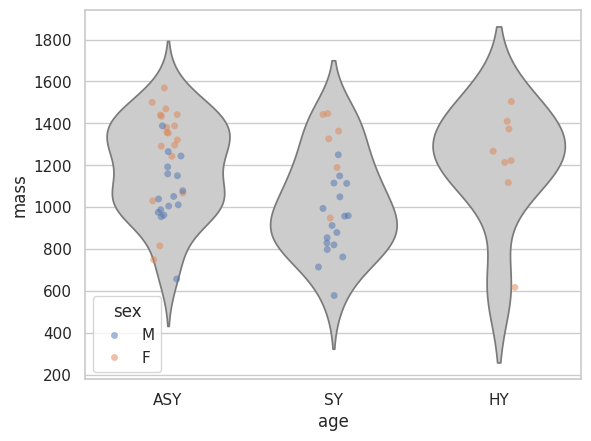

In [224]:
comboplot('mass')

We have one outlier amongst the juveniles. If we had access to the original data, I'd check this for for a potential data entry error.

`wing`

This is a measure of the wing length.

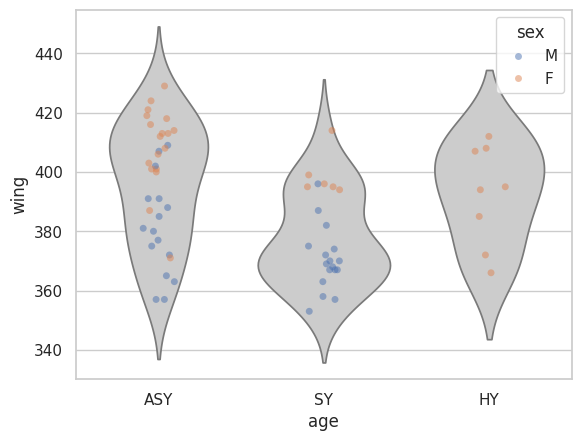

In [225]:
comboplot('wing')

Fairly strong pattern of larger females for non-juveniles. And, of course, with the juveniles we just can't tell.

`hallux`

The **hallux** is the bird’s **"big toe."**

Specifically, it is the digit that points **backward** on a hawk's foot (scientifically referred to as "Toe 1"). While humans have a hallux that points forward (our big toe), most birds have a hallux that has rotated to the back to help them grip branches or prey.

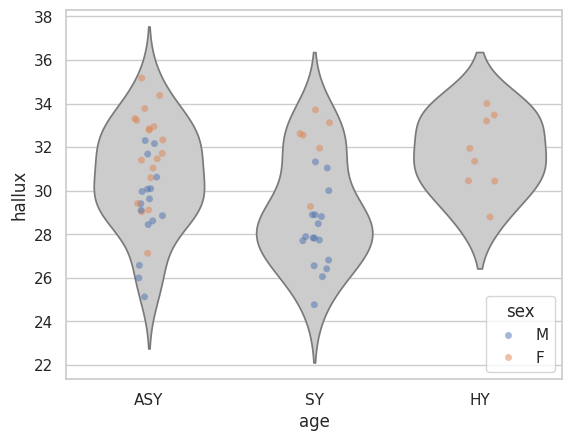

In [226]:
comboplot('hallux')

`culmen`

The **culmen** refers to the upper ridge of the bird's beak. If you imagine the hawk's beak as the roof of a house, the culmen is the "peak" or the ridge line that runs down the center of the upper mandible.



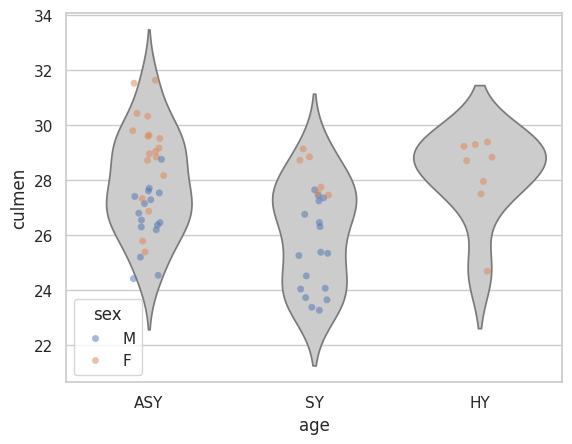

In [227]:
comboplot('culmen')

`tail`

The **Tail** measurement (often recorded as "Tail Length") is the distance from the base of the tail feathers to the tip of the longest feather.

Specifically, researchers measure from the point where the two central tail feathers (called **rectrices**) emerge from the skin (the uropygium) to the very end of the feathers.

Here is why this measurement is included and what it tells you:

### 1. Determining Sex (Size Dimorphism)
Just like the Hallux and Culmen, the tail is a key indicator of the bird's overall size.
*   **Females:** Generally have longer tails.
*   **Males:** Generally have shorter tails.

### 2. Distinguishing Age (HY vs. ASY)
*   **Juvenile (HY) hawks often have longer tails than adults (ASY).**
*   **Why?** Juvenile hawks are "learning to drive." Longer tail feathers provide more surface area, which creates more lift and stability. This helps a young, clumsy hawk stay stable while learning to hunt and soar.
*   Once they molt into their adult feathers (ASY), the feathers grow back slightly shorter but stiffer, which is more efficient for high-speed maneuvering and long-term durability.

### 3. Feather Wear and Health
If you see a tail measurement that is unusually short for an ASY bird, it might be noted in the dataset as "worn" or "broken." This tells researchers about the bird's environment or whether it has been struggling with poor nutrition (which can lead to brittle feathers).


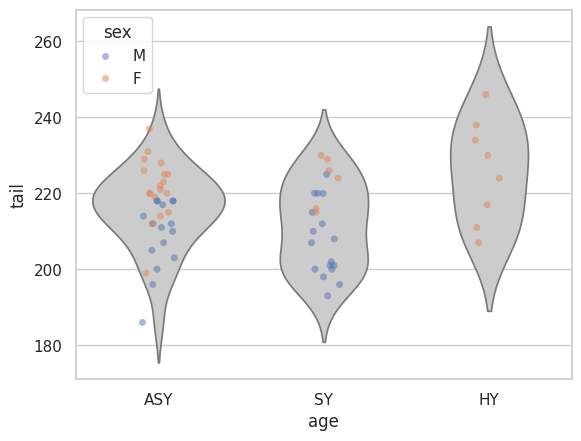

In [228]:
comboplot('tail')

`tarsus`

The tarsus refers to the bird's lower leg.
Technically called the tarsometatarsus, it is the long, scaly bone between what looks like the hawk's backward-facing "knee" (the intertarsal joint) and the base of its toes.

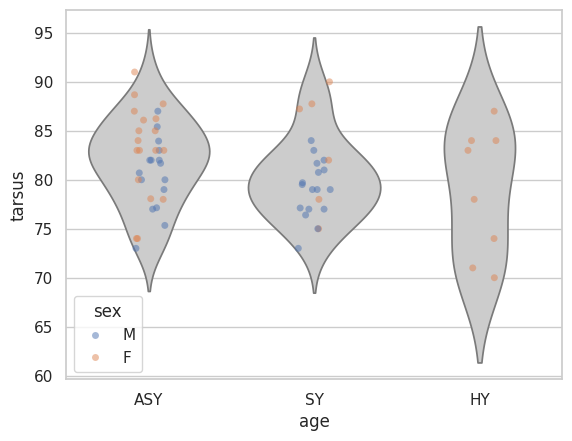

In [229]:
comboplot('tarsus')

Not as clear a pattern here, but still it generally looks like the larger the feature, the more likely you are to have a female hawk.

In [230]:
df.columns

Index(['sex', 'date', 'age', 'mass', 'wing', 'hallux', 'culmen', 'tail',
       'tarsus'],
      dtype='object')

In [231]:
#  change to suppress selected visualizations
make_big_plots = True

# set size of test set
tsize = .35

# set random state
rstate = 24

# Identify Columns Types

In [232]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
nonnum_cols = [col for col in df.columns if col not in num_cols]


### Correlations and Heatmap

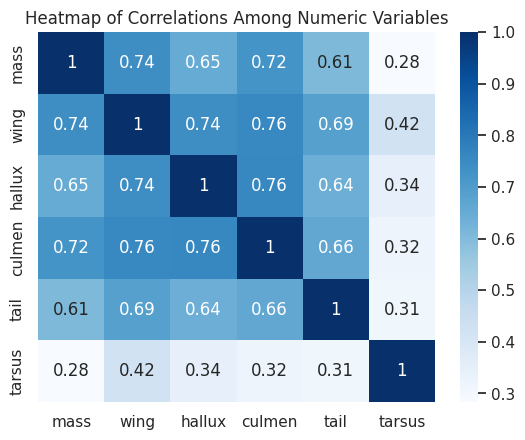

In [233]:
sns.heatmap(df[num_cols].corr(),
            cmap='Blues',
            annot=True)
plt.title('Heatmap of Correlations Among Numeric Variables')
plt.show()

# Classification of Sex

## Classifcation Helper Functions

In [234]:
import pandas as pd

# table to compare model performance
ct_cols = ['features','model',
           'aw_precision','aw_recall','aw_f1score',
           'actFpredF','actFpredM',
           'actMpredF','actMpredM',
           'notes']

comparison_table = pd.DataFrame(columns=ct_cols)

def add_results(ctable, feature_label, method_label, y, yhat, plabel, notes):
  '''
  takes: feature and model description, results table
  calculates: selected metrics
  returns: the results table updated with model and metrics
  '''
  # get average weighted metrics from classification report
  classreport = classification_report(y, yhat, output_dict=True)
  pscore = classreport['weighted avg']['precision']
  recall = classreport['weighted avg']['recall']
  f1score = classreport['weighted avg']['f1-score']

  # get classification counts from confusion matrix
  cm = confusion_matrix(y, yhat)
  actFpredF = cm[0][0]
  actFpredM = cm[0][1]
  actMpredF = cm[1][0]
  actMpredM = cm[1][1]

  results = [feature_label, method_label, pscore, recall, f1score,
             actFpredF, actFpredM, actMpredF, actMpredM, notes]
  ctable = pd.concat([ctable, pd.DataFrame([results], columns = ct_cols)], ignore_index=True)
  return ctable

def detailed_classification_report(X, y, type):
  print(f'\nDetailed Classification Report - {type}\n')
  predictions = model.predict(X)
  probability = model.predict_proba(X)[:, 1]
  predicted = model.predict(X)

  print('Log loss      = {:.2f}'.format(log_loss(y, probability)))
  print('AUC           = {:.2f}'.format(roc_auc_score(y, probability)))
  print('Avg Precision = {:.2f}\n'.format(average_precision_score(y, probability)))

  print(classification_report(y, predicted),'\n')

# age masks
mask_hy = df['age']=='HY'
mask_sy = df['age']=='SY'
mask_asy = df['age']=='ASY'

## Washburn (2022)

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 0 to 65
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   sex     65 non-null     object        
 1   date    65 non-null     datetime64[ns]
 2   age     65 non-null     object        
 3   mass    65 non-null     int64         
 4   wing    65 non-null     int64         
 5   hallux  65 non-null     float64       
 6   culmen  65 non-null     float64       
 7   tail    65 non-null     int64         
 8   tarsus  65 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 5.1+ KB


In [236]:
df.loc[mask_hy, 'washburn_d'] = -18.11344 + (0.00943*df['mass']) + (0.26661*df['hallux'])
df.loc[mask_sy, 'washburn_d'] = -33.21806 + (0.01261*df['mass']) + (0.04955*df['wing'])
df.loc[mask_asy, 'washburn_d'] = -40.31743 + (0.01279*df['mass'])+ (0.04259*df['wing']) + (0.04134*df['tail'])
df.loc[df['washburn_d'] > 0, 'sex_wsh'] = 'F'
df.loc[df['washburn_d'] < 0, 'sex_wsh'] = 'M'

In [237]:
#classification_results('Washburn (2022)', df.sex, df.sex_wsh, 'F')
comparison_table = add_results(comparison_table,
                              'Full Model',
                              'Washburn(22)',
                              df.sex, df.sex_wsh,
                              'F', 'No notes')

/tmp/ipykernel_26701/2703617169.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ctable = pd.concat([ctable, pd.DataFrame([results], columns = ct_cols)], ignore_index=True)


## Donohue and Duffy (2006) Equations

In [238]:
df.loc[(mask_hy | mask_sy), 'donduff_d'] = 0.2 * (df['wing']) + \
        (0.011*df['mass']) + (1.302*df['hallux']) + (1.356*df['culmen'])
df.loc[mask_asy, 'donduff_d'] = (0.026*df['mass']) + (0.166*df['wing'])

df.loc[((mask_hy | mask_sy) & df['donduff_d'] > 160.933), 'sex_dd'] = 'F'
df.loc[((mask_hy | mask_sy) & df['donduff_d'] <= 160.933), 'sex_dd'] = 'M'

df.loc[(mask_asy) & (df['donduff_d'] > 94.902), 'sex_dd'] = 'F'
df.loc[(mask_asy) & (df['donduff_d'] <= 94.902), 'sex_dd'] = 'M'

In [239]:
comparison_table = add_results(comparison_table,
            'Full Model',
            'DonahueDuffy(06)',
            df.sex, df.sex_dd,
            'F', 'No notes')

## Donohue and Duffy Modified

In [240]:
df.loc[(mask_hy | mask_sy), 'donduff_dm'] = 0.2 * (df['wing']) + \
        (0.011*df['mass']) + (1.302*df['hallux']) + (1.356*df['culmen'])
df.loc[mask_asy, 'donduff_dm'] = (0.026*df['mass']) + (0.156*df['wing']) # very minor change to wing beta

df.loc[((mask_hy | mask_sy) & df['donduff_dm'] > 160.933), 'sex_ddm'] = 'F'
df.loc[((mask_hy | mask_sy) & df['donduff_dm'] <= 160.933), 'sex_ddm'] = 'M'

df.loc[(mask_asy) & (df['donduff_dm'] > 94.902), 'sex_ddm'] = 'F'
df.loc[(mask_asy) & (df['donduff_dm'] <= 94.902), 'sex_ddm'] = 'M'

In [241]:
comparison_table = add_results(comparison_table,
            'Full Model',
            'DonahueDuffy-Mod',
            df.sex, df.sex_dd,
            'F', 'No notes')

In [242]:
comparison_table

,features,model,aw_precision,aw_recall,aw_f1score,actFpredF,actFpredM,actMpredF,actMpredM,notes
0,Full Model,Washburn(22),0.785900,0.784615,0.784513,26,6,8,25,No notes
1,Full Model,DonahueDuffy(06),0.708731,0.676923,0.662329,15,17,4,29,No notes
2,Full Model,DonahueDuffy-Mod,0.708731,0.676923,0.662329,15,17,4,29,No notes


## Logistic Regression

In [243]:
X = df[['age', 'mass', 'wing', 'hallux', 'culmen', 'tail', 'tarsus']]
y = df['sex']

numeric_features = ['mass', 'wing', 'hallux', 'culmen', 'tail','tarsus']
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_features = ["age"]
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = LogisticRegression(solver='saga', max_iter=8000)

pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', model)])

trainX, testX, trainY, testY = train_test_split(X,
                                                y,
                                                test_size = tsize,
                                                stratify=y,
                                                random_state = rstate)

pipe.fit(trainX, trainY)

predictions = pipe.predict(testX)

comparison_table = add_results(comparison_table,
            'Full Model - Linear',
            'Logistic Regression',
            testY, predictions,
            'F', 'solver: saga')


print('Model Results: Classification of Test Set\n')
print(classification_report(testY, predictions))

Model Results: Classification of Test Set

              precision    recall  f1-score   support

           F       0.77      0.91      0.83        11
           M       0.90      0.75      0.82        12

    accuracy                           0.83        23
   macro avg       0.83      0.83      0.83        23
weighted avg       0.84      0.83      0.83        23



## Random Forrest

In [244]:
X = df[['age', 'mass', 'wing', 'hallux', 'culmen', 'tail', 'tarsus']]
y = df['sex']

numeric_features = ['mass', 'wing', 'hallux', 'culmen', 'tail','tarsus']
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_features = ["age"]
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = RandomForestClassifier(n_estimators=500,
                               max_depth=6,
                               random_state=0)


trainX, testX, trainY, testY = train_test_split(X,
                                                y,
                                                test_size = tsize,
                                                stratify=y,
                                                random_state = rstate)

pipe.fit(trainX, trainY)

predictions = pipe.predict(testX)

comparison_table = add_results(comparison_table,
            'Full Model - Linear',
            'Random Forrest',
            testY, predictions,
            'F', 'max depth: 6')

# print results
print('Model Results: Classification of Test Set\n')
print(classification_report(testY, predictions))

Model Results: Classification of Test Set

              precision    recall  f1-score   support

           F       0.77      0.91      0.83        11
           M       0.90      0.75      0.82        12

    accuracy                           0.83        23
   macro avg       0.83      0.83      0.83        23
weighted avg       0.84      0.83      0.83        23



## Support Vector Machine

In [245]:
X = df[['age', 'mass', 'wing', 'hallux', 'culmen', 'tail', 'tarsus']]
y = df['sex']

numeric_features = ['mass', 'wing', 'hallux', 'culmen', 'tail','tarsus']
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_features = ["age"]
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = svm.SVC(class_weight='balanced')

pipe = Pipeline(steps=[('preprocessor', preprocessor),
                       ('classifier', model)])

trainX, testX, trainY, testY = train_test_split(X,
                                                y,
                                                test_size = tsize,
                                                stratify=y,
                                                random_state = rstate)

pipe.fit(trainX, trainY)

predictions = pipe.predict(testX)

comparison_table = add_results(comparison_table,
            'Full Model - Linear',
            'Support Vector Machine',
            testY, predictions,
            'F', 'cw: balanced')

print('Model Results: Classification of Test Set\n')
print(classification_report(testY, predictions))

Model Results: Classification of Test Set

              precision    recall  f1-score   support

           F       0.83      0.91      0.87        11
           M       0.91      0.83      0.87        12

    accuracy                           0.87        23
   macro avg       0.87      0.87      0.87        23
weighted avg       0.87      0.87      0.87        23



# Comparison of Classification Results

In [246]:
comparison_table.round(2)

,features,model,aw_precision,aw_recall,aw_f1score,actFpredF,actFpredM,actMpredF,actMpredM,notes
0,Full Model,Washburn(22),0.79,0.78,0.78,26,6,8,25,No notes
1,Full Model,DonahueDuffy(06),0.71,0.68,0.66,15,17,4,29,No notes
2,Full Model,DonahueDuffy-Mod,0.71,0.68,0.66,15,17,4,29,No notes
3,Full Model - Linear,Logistic Regression,0.84,0.83,0.83,10,1,3,9,solver: saga
4,Full Model - Linear,Random Forrest,0.84,0.83,0.83,10,1,3,9,max depth: 6
5,Full Model - Linear,Support Vector Machine,0.87,0.87,0.87,10,1,2,10,cw: balanced
